# 03 — Customer value & purchase behavior
### Olist Brazilian E-Commerce · `retail-platform-analytics`

The obvious next step after the EDA was a **customer segmentation** (the classic *RFM* model:
Recency, Frequency, Monetary). But Olist's data **breaks all three RFM axes**, so a textbook
segmentation would produce tautologies ("high spenders drive revenue") rather than insight.

This notebook does the honest version: it shows *why* RFM collapses here, then finds what **actually**
explains customer value — and the answer is not how *often* or how *much* customers buy, but the
**price-point of what they buy**. That turns "who is a valuable customer?" into a product/acquisition
question, which is genuinely actionable.

## Data caveats & conventions

- **Grain:** one row per customer. Built from `fct_order_items` joined to `fct_orders` (so we can see
  items, prices, and categories), aggregated to the person-level `customer_id` (correctly resolved to
  `customer_unique_id` in dbt — see notebook `01`).
- **Ticket** = a customer's average item price (`avg(price)`); **basket** = number of items; a
  customer's **value** = total item revenue.
- **⚠️ No product-cost data**, so "value" here is revenue, not margin (margin is proxied by freight in
  `04`).
- Categories use the English `category_name`; ~1.6% of items with a null category are excluded from
  the category cut.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

# One customer-level pull reused throughout: orders, items, spend, and average ticket per customer.
cust = q('''
    select o.customer_id,
           count(distinct oi.order_id) as n_orders,   -- frequency
           count(*)                    as n_items,     -- basket size (total items bought)
           sum(oi.total_item_value)    as total_value, -- the customer's revenue
           avg(oi.price)               as avg_ticket   -- typical price point they buy at
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    group by 1
''')
for c in ["n_orders", "n_items", "total_value", "avg_ticket"]:
    cust[c] = pd.to_numeric(cust[c], errors="coerce")
print(f"{len(cust):,} customers")

95,420 customers


## 1. Why the RFM playbook doesn't fit Olist

RFM segments customers on **R**ecency, **F**requency, and **M**onetary value. For it to be useful, at
least Frequency and Monetary need to *vary*. Let's check.

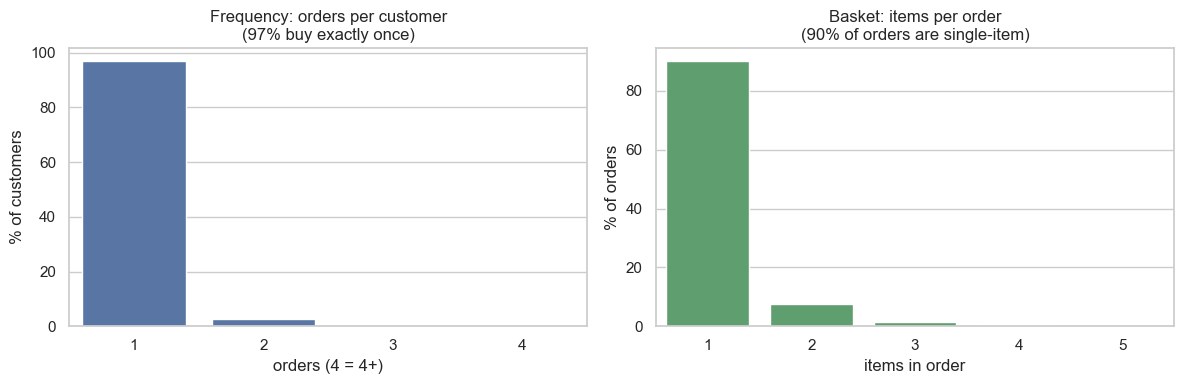

Frequency: 96.9% of customers order once | Basket: 90.1% of orders are single-item


In [2]:
# Frequency (orders per customer) and basket size (items per order) — do they vary?
freq_one = 100 * (cust["n_orders"] == 1).mean()
basket = q('''
    select n_items, count(*) as orders
    from (select order_id, count(*) as n_items from dev_marts.fct_order_items group by 1)
    group by 1 order by 1
''')
basket["pct"] = 100 * basket["orders"] / basket["orders"].sum()
basket_one = basket.loc[basket["n_items"] == 1, "pct"].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Left: orders per customer (Frequency axis)
oc = cust["n_orders"].clip(upper=4).value_counts(normalize=True).sort_index() * 100
sns.barplot(x=oc.index, y=oc.values, ax=ax1, color="#4C72B0")
ax1.set_title(f"Frequency: orders per customer\n({freq_one:.0f}% buy exactly once)")
ax1.set_xlabel("orders (4 = 4+)"); ax1.set_ylabel("% of customers")
# Right: items per order (basket size)
sns.barplot(data=basket[basket["n_items"] <= 5], x="n_items", y="pct", ax=ax2, color="#55A868")
ax2.set_title(f"Basket: items per order\n({basket_one:.0f}% of orders are single-item)")
ax2.set_xlabel("items in order"); ax2.set_ylabel("% of orders")
plt.tight_layout(); plt.show()
print(f"Frequency: {freq_one:.1f}% of customers order once | Basket: {basket_one:.1f}% of orders are single-item")

**Two of the three RFM axes are degenerate.**
- **Frequency ≈ 1:** ~97% of customers order only once — there is no purchase-frequency ladder to tier.
- **Basket ≈ 1:** ~90% of orders contain a single item — no "big basket vs small basket" spread either.
- That leaves **Monetary** (total spend) as the only axis with real variance — but segmenting customers
  by spend and concluding "big spenders drive revenue" is circular: spend *is* revenue.

So RFM would just relabel the revenue distribution. We need a lens that explains *why* some customers
are worth more — decomposing their spend into its parts.

## 2. What actually drives customer value — ticket, not quantity

A customer's value ≈ **number of items × average item price**. If value is driven by *quantity*, big
spenders buy *more things*; if by *ticket*, they buy *pricier things*. Test which, by correlating each
with total value.

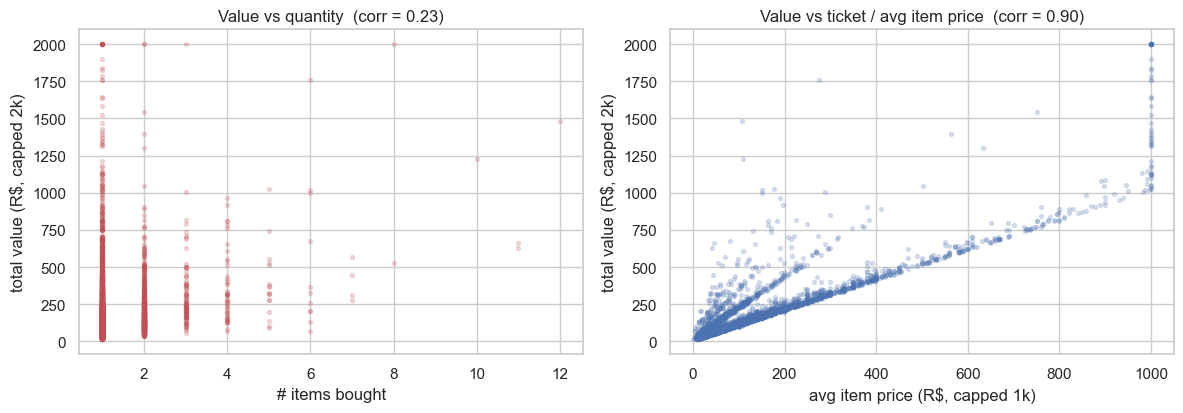

corr(value, #items) = 0.23   vs   corr(value, ticket) = 0.90


In [3]:
corr_qty = cust["total_value"].corr(cust["n_items"])
corr_ticket = cust["total_value"].corr(cust["avg_ticket"])

# Sample for readable scatters (95k points would be a blob).
s = cust.sample(min(6000, len(cust)), random_state=1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.scatter(s["n_items"], s["total_value"].clip(upper=2000), s=8, alpha=0.2, color="#C44E52")
ax1.set_title(f"Value vs quantity  (corr = {corr_qty:.2f})")
ax1.set_xlabel("# items bought"); ax1.set_ylabel("total value (R$, capped 2k)")
ax2.scatter(s["avg_ticket"].clip(upper=1000), s["total_value"].clip(upper=2000), s=8, alpha=0.2, color="#4C72B0")
ax2.set_title(f"Value vs ticket / avg item price  (corr = {corr_ticket:.2f})")
ax2.set_xlabel("avg item price (R$, capped 1k)"); ax2.set_ylabel("total value (R$, capped 2k)")
plt.tight_layout(); plt.show()
print(f"corr(value, #items) = {corr_qty:.2f}   vs   corr(value, ticket) = {corr_ticket:.2f}")

**Customer value is a ticket story, not a quantity story.** Total value tracks **average item
price at ≈0.90** but **number of items at only ≈0.23**. In plain terms: valuable customers are the ones
who buy **one expensive thing**, not many cheap things. So the real question isn't *how much* a customer
buys — it's **what price-point they buy at**, which is really a question about *which product*.

## 3. Value tiers are price-point tiers

Split customers into three equal groups by their average ticket — **Budget / Mid / Premium** — and see
how revenue and basket size distribute.

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_56919/1315629237.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier, x="tier", y="rev_share_pct", ax=ax, palette=["#8FB0D6", "#4C72B0", "#2A3F5F"])


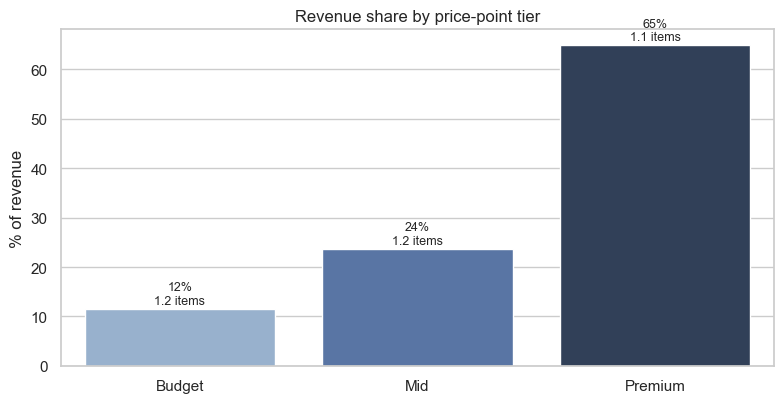

,tier,customers,ticket_lo,ticket_hi,avg_items,avg_spend,rev_share_pct
0,Budget,31807,0.80,52.50,1.20,57.40,11.50
1,Mid,31806,52.50,115.00,1.20,117.60,23.60
2,Premium,31807,115.00,"6,735.00",1.10,323.10,64.90


In [4]:
# Tercile customers by average ticket (rank first so the three groups are exactly equal).
cust["tier"] = pd.qcut(cust["avg_ticket"].rank(method="first"), 3, labels=["Budget", "Mid", "Premium"])
tier = cust.groupby("tier", observed=True).agg(
    customers=("customer_id", "size"),
    ticket_lo=("avg_ticket", "min"),
    ticket_hi=("avg_ticket", "max"),
    avg_items=("n_items", "mean"),
    revenue=("total_value", "sum"),
    avg_spend=("total_value", "mean")).reset_index()
tier["rev_share_pct"] = 100 * tier["revenue"] / tier["revenue"].sum()

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=tier, x="tier", y="rev_share_pct", ax=ax, palette=["#8FB0D6", "#4C72B0", "#2A3F5F"])
ax.set_title("Revenue share by price-point tier"); ax.set_xlabel(""); ax.set_ylabel("% of revenue")
for i, r in tier.iterrows():
    # Annotate each bar with revenue share AND avg items — to show basket size stays flat across tiers.
    ax.text(i, r["rev_share_pct"] + 1, f"{r['rev_share_pct']:.0f}%\n{r['avg_items']:.1f} items", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
tier[["tier", "customers", "ticket_lo", "ticket_hi", "avg_items", "avg_spend", "rev_share_pct"]].round(1)

**The premium third of customers drives ~65% of revenue; the budget third just ~12%.** But note the
annotation: **average basket size is ~1.1–1.2 items in *every* tier** — premium customers are not buying
*more*, they are buying *pricier*. This is the ticket finding again, now as a segmentation: value tiers
*are* price-point tiers.

## 4. What each tier buys — the actionable payoff

If value is about price-point, then "who is valuable" collapses into "**what did they buy**". Compare
the categories Budget vs Premium customers actually purchase.

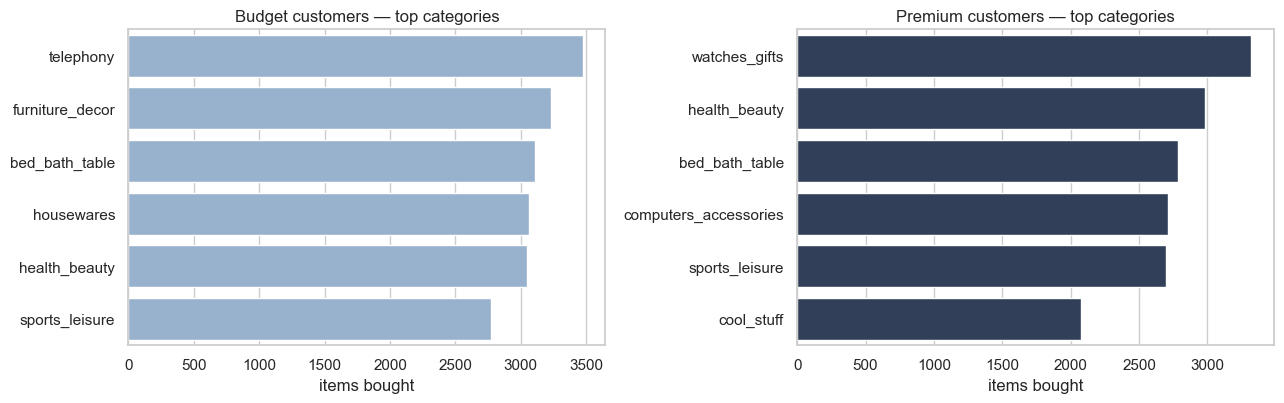

In [5]:
# Item-level categories tagged with each customer's tier, then top categories per tier.
items = q('''
    select o.customer_id, oi.category_name
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    where oi.category_name is not null
''').merge(cust[["customer_id", "tier"]], on="customer_id")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, t, color in [(axes[0], "Budget", "#8FB0D6"), (axes[1], "Premium", "#2A3F5F")]:
    top = items[items["tier"] == t]["category_name"].value_counts().head(6)
    sns.barplot(x=top.values, y=top.index, ax=ax, color=color)
    ax.set_title(f"{t} customers — top categories"); ax.set_xlabel("items bought"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**The tiers buy genuinely different things.** Budget customers cluster in cheaper home and phone
goods — `telephony`, `furniture_decor`, `housewares`, `bed_bath_table`. Premium customers buy
`watches_gifts`, `health_beauty`, and `computers_accessories`. So the "high-value customer" is not a
loyalty or behaviour type at all — it's **whoever entered through a high-ticket category**. That reframes
retention/loyalty programs (which have nothing to work with here) into an **acquisition + merchandising**
problem: attract customers into premium categories. It also dovetails with `04`, where `watches_gifts`
and `health_beauty` are the margin-safe revenue drivers — the same categories that define premium
customers.

## 5. Findings & recommendations

### What we found
1. **RFM doesn't apply.** ~97% of customers buy once and ~90% of orders are single-item — Frequency and
   Basket are both degenerate, and segmenting on Monetary alone is circular (spend = revenue).
2. **Value is driven by ticket, not quantity** — total value correlates with average item price at ≈0.90
   vs ≈0.23 for item count. Valuable customers buy *pricier things*, not *more things*.
3. **Value tiers are price-point tiers, and they map to categories.** The premium third (by ticket) is
   ~65% of revenue and buys watches, health & beauty, and computers; the budget third (~12% of revenue)
   buys telephony and cheap home goods.

### Recommendations (if live)
- **Treat customer value as an acquisition & merchandising problem, not a loyalty one** — there is no
  repeat/frequency behaviour to cultivate. Grow value by **acquiring into premium categories** and
  raising the entry price-point (cross-sell/upsell at checkout).
- **Prioritise the margin-safe premium categories** (`watches_gifts`, `health_beauty`,
  `computers_accessories`) — high ticket *and*, per `04`, low freight drag.
- **Don't over-invest in retention tooling** — with ~3% repeat, reactivation of past high-ticket buyers
  is the only "loyalty" lever, and it's small.

### Backlog
The analysis layer (`01`–`04` + `00`) now covers growth, delivery→satisfaction, customer value, and
category/freight economics. A live/incremental pipeline would unlock the missing dimension — genuine
**cohort retention** over time — which this static two-year snapshot cannot support.